In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv
import warnings
import os

from scipy.optimize import brentq

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter("ignore", pd.errors.SettingWithCopyWarning)

In [4]:
folder = os.fsencode("data/tennis")
dataframes = []
for file in sorted(os.listdir(folder)):
    filename = os.fsdecode(file)
    if filename.endswith(".csv"):
        df = pd.read_csv("data/tennis/" + filename)
        dataframes.append(df)

data = pd.concat(dataframes, axis=0)

In [7]:
data = data[[
    "Date", "Round", "Winner", "Loser", "WRank", "LRank", "B365W", "B365L", "AvgW", "AvgL"
]]
data["B365W"] = pd.to_numeric(data["B365W"], errors="coerce")
data = data.dropna()
odds_columns = ["B365W", "B365L", "AvgW", "AvgL"]
data = data[data[odds_columns].ge(1).all(axis=1)]
data = data.reset_index(drop=True)
data.describe()

,WRank,LRank,B365W,B365L,AvgW,AvgL
count,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000
mean,49.139241,88.679589,1.796334,5.111618,1.794199,4.824521
std,60.241328,97.331659,1.400419,5.591138,1.339577,4.522396
min,1.000000,1.000000,1.000000,1.010000,1.000000,1.010000
25%,10.000000,36.000000,1.140000,1.910000,1.140000,1.930000
50%,30.000000,70.000000,1.360000,3.200000,1.360000,3.130000
75%,69.000000,108.000000,1.900000,5.500000,1.862500,5.810000
max,849.000000,1848.000000,29.000000,51.000000,21.200000,33.420000


In [9]:
odds_columns = ['B365L', 'AvgL']
data[data[odds_columns].lt(1.011).any(axis=1)]

,Date,Round,Winner,Loser,WRank,LRank,B365W,B365L,AvgW,AvgL
211,19/01/17,2nd Round,Istomin D.,Djokovic N.,117.0,2.0,23.0,1.01,21.20,1.01
2740,30/08/2024,2nd Round,Van De Zandschulp B.,Alcaraz C.,74.0,3.0,29.0,1.01,19.07,1.01
4902,02/07/16,3rd Round,Querrey S.,Djokovic N.,41.0,1.0,26.0,1.01,20.78,1.01


In [11]:
data["booksum"] = (1/data["B365W"]) + (1/data["B365L"])

In [13]:
data.describe()

,WRank,LRank,B365W,B365L,AvgW,AvgL,booksum
count,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000
mean,49.139241,88.679589,1.796334,5.111618,1.794199,4.824521,1.051923
std,60.241328,97.331659,1.400419,5.591138,1.339577,4.522396,0.008845
min,1.000000,1.000000,1.000000,1.010000,1.000000,1.010000,1.019511
25%,10.000000,36.000000,1.140000,1.910000,1.140000,1.930000,1.047619
50%,30.000000,70.000000,1.360000,3.200000,1.360000,3.130000,1.053348
75%,69.000000,108.000000,1.900000,5.500000,1.862500,5.810000,1.057111
max,849.000000,1848.000000,29.000000,51.000000,21.200000,33.420000,1.133559


In [15]:
data["multiplicativeWinner"] = 1 / (data["B365W"] * data["booksum"])
data["multiplicativeLoser"] = 1 / (data["B365L"] * data["booksum"])

In [17]:
def f(odds: list, k: float) -> float:
    total = 0
    for odd in odds:
        total += (1/odd)**k
    return total - 1

def df(odds: list, k: float) -> float:
    total = 0
    for odd in odds:
        total += (1/odd)**k * np.log(1/odd)
    return total


def getPowerProbs(odds: list) -> list:
    xn = 1
    xn1 = 0
    epsilon = 1e-8

    while np.abs(xn1 - xn) > epsilon:
        xn = xn1
        xn1 = xn - (f(odds, xn) / df(odds, xn))

    newOdds = np.power(odds, xn1)
    newProbs = np.divide(1, newOdds)
    return newProbs

def getPowerProbsRow(row):
    odds = [row["B365W"], row["B365L"]]
    probs = getPowerProbs(odds)
    return pd.Series({"powerWinner": probs[0], "powerLoser": probs[1]})

data[["powerWinner", "powerLoser"]] = data.apply(getPowerProbsRow, axis=1)

In [18]:
def getShinProbabilities(odds):
    odds = np.array(odds)
    pi = 1/odds
    Pi = np.sum(pi)

    def p_i(z, pi_i):
        numerator = -z + np.sqrt(z**2 + 4*(1-z)*(pi_i**2 / Pi))
        denominator = 2*(1-z)
        return numerator / denominator

    def g(z):
        return sum(p_i(z, pi_i) for pi_i in pi) - 1

    z_star = brentq(g, 1e-8, 1 - 1e-8)
    probs = np.array([p_i(z_star, pi_i) for pi_i in pi])

    return probs, z_star

def getShinProbabilitiesRow(row):
    odds = [row["B365W"], row["B365L"]]
    probs, z_star = getShinProbabilities(odds)
    return pd.Series({"shinWinner": probs[0], "shinLoser": probs[1], "z": z_star})

data[["shinWinner", "shinLoser", "z"]] = data.apply(getShinProbabilitiesRow, axis=1)

In [21]:
data.describe()

,WRank,LRank,B365W,B365L,AvgW,AvgL,booksum,multiplicativeWinner,multiplicativeLoser,powerWinner,powerLoser,shinWinner,shinLoser,z
count,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5.056000e+03,5056.000000,5056.000000,5056.000000
mean,49.139241,88.679589,1.796334,5.111618,1.794199,4.824521,1.051923,0.656189,0.343811,0.668480,3.315203e-01,0.663660,0.336340,0.053858
std,60.241328,97.331659,1.400419,5.591138,1.339577,4.522396,0.008845,0.218988,0.218988,0.236156,2.361564e-01,0.229406,0.229406,0.008025
min,1.000000,1.000000,1.000000,1.010000,1.000000,1.010000,1.019511,0.033655,0.019231,0.012797,6.554014e-17,0.022192,0.009804,0.023982
25%,10.000000,36.000000,1.140000,1.910000,1.140000,1.930000,1.047619,0.500000,0.171687,0.500000,1.401718e-01,0.500000,0.152313,0.048460
50%,30.000000,70.000000,1.360000,3.200000,1.360000,3.130000,1.053348,0.701754,0.298246,0.716563,2.834372e-01,0.711397,0.288603,0.055341
75%,69.000000,108.000000,1.900000,5.500000,1.862500,5.810000,1.057111,0.828313,0.500000,0.859828,5.000000e-01,0.847687,0.500000,0.057621
max,849.000000,1848.000000,29.000000,51.000000,21.200000,33.420000,1.133559,0.980769,0.966345,1.000000,9.872031e-01,0.990196,0.977808,0.136058


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

np.random.seed(42)
flip = np.random.rand(len(data)) > 0.5
X = pd.DataFrame({
    "odds_p1": np.where(flip, data["B365W"], data["B365L"]),
    "odds_p2": np.where(flip, data["B365L"], data["B365W"]),
}, index=data.index)
y = pd.Series(flip.astype(int), index=data.index)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)
probs_p1 = model.predict_proba(X_test)[:, 1]

# flip tells us whether p1 = winner; map back accordingly
flip_test = flip[X_test.index]
prob_winner = np.where(flip_test, probs_p1, 1 - probs_p1)
prob_loser  = 1 - prob_winner

data["logisticProbWinner"] = np.nan
data["logisticProbLoser"]  = np.nan
data.loc[X_test.index, "logisticProbWinner"] = prob_winner
data.loc[X_test.index, "logisticProbLoser"]  = prob_loser

data.tail()

,Date,Round,Winner,Loser,WRank,LRank,B365W,B365L,AvgW,AvgL,booksum,multiplicativeWinner,multiplicativeLoser,powerWinner,powerLoser,shinWinner,shinLoser,z,logisticProbWinner,logisticProbLoser
5051,09/07/2025,Quarterfinals,Sinner J.,Shelton B.,1.0,10.0,1.25,3.60,1.29,3.58,1.077778,0.742268,0.257732,0.772595,0.227405,0.761111,0.238889,0.079882,NaN,NaN
5052,09/07/2025,Quarterfinals,Djokovic N.,Cobolli F.,6.0,24.0,1.10,7.00,1.09,7.53,1.051948,0.864198,0.135802,0.895342,0.104658,0.883117,0.116883,0.055596,0.913727,0.086273
5053,11/07/2025,Semifinals,Alcaraz C.,Fritz T.,2.0,5.0,1.17,4.75,1.17,4.98,1.065227,0.802365,0.197635,0.834318,0.165682,0.822087,0.177913,0.068060,NaN,NaN
5054,11/07/2025,Semifinals,Sinner J.,Djokovic N.,1.0,6.0,1.40,2.80,1.42,2.85,1.071429,0.666667,0.333333,0.685333,0.314667,0.678571,0.321429,0.072125,0.624080,0.375920
5055,13/07/2025,The Final,Sinner J.,Alcaraz C.,1.0,2.0,1.83,2.00,1.82,1.98,1.046448,0.522193,0.477807,0.523749,0.476251,0.523224,0.476776,0.046453,NaN,NaN


In [25]:
data_test = data.loc[X_test.index].copy()
data_test.head()

,Date,Round,Winner,Loser,WRank,LRank,B365W,B365L,AvgW,AvgL,booksum,multiplicativeWinner,multiplicativeLoser,powerWinner,powerLoser,shinWinner,shinLoser,z,logisticProbWinner,logisticProbLoser
3106,02/09/2021,2nd Round,Basilashvili N.,Cressy M.,39.0,151.0,1.44,2.75,1.47,2.71,1.058081,0.656325,0.343675,0.670328,0.329672,0.665404,0.334596,0.058473,0.624216,0.375784
2581,27/05/2025,1st Round,Monfils G.,Dellien H.,42.0,90.0,1.33,3.40,1.33,3.41,1.045997,0.718816,0.281184,0.734291,0.265709,0.728881,0.271119,0.046534,0.683170,0.316830
2820,29/08/2023,1st Round,Rublev A.,Cazaux A.,8.0,119.0,1.14,5.50,1.15,5.66,1.059011,0.828313,0.171687,0.859828,0.140172,0.847687,0.152313,0.062090,0.823786,0.176214
751,18/02/2021,Semifinals,Djokovic N.,Karatsev A.,1.0,114.0,1.07,9.00,1.07,8.72,1.045691,0.893744,0.106256,0.923791,0.076209,0.911734,0.088266,0.049896,0.938712,0.061288
1209,15/01/2025,2nd Round,Paul T.,Nishikori K.,11.0,76.0,1.40,3.00,1.41,2.88,1.047619,0.681818,0.318182,0.695067,0.304933,0.690476,0.309524,0.047986,0.647225,0.352775


In [27]:
data_test.describe()

,WRank,LRank,B365W,B365L,AvgW,AvgL,booksum,multiplicativeWinner,multiplicativeLoser,powerWinner,powerLoser,shinWinner,shinLoser,z,logisticProbWinner,logisticProbLoser
count,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1.012000e+03,1012.000000,1012.000000,1012.000000,1012.000000,1.012000e+03
mean,47.346838,91.967391,1.803510,5.221907,1.795889,4.857421,1.051963,0.659298,0.340702,0.671845,3.281549e-01,0.666928,0.333072,0.053955,0.662199,3.378011e-01
std,57.957890,104.225294,1.428631,5.873840,1.351591,4.522499,0.008945,0.219206,0.219206,0.236365,2.363646e-01,0.229592,0.229592,0.008005,0.229535,2.295345e-01
min,1.000000,1.000000,1.000000,1.020000,1.010000,1.020000,1.019511,0.050949,0.019231,0.024608,6.554014e-17,0.036120,0.009804,0.023982,0.002336,5.887190e-08
25%,10.000000,36.000000,1.140000,2.000000,1.140000,1.960000,1.047619,0.526316,0.171687,0.528543,1.401718e-01,0.527778,0.152313,0.048269,0.510134,1.523980e-01
50%,27.500000,69.500000,1.360000,3.200000,1.350000,3.215000,1.053348,0.701754,0.298246,0.716563,2.834372e-01,0.711397,0.288603,0.055341,0.665902,3.340977e-01
75%,66.000000,108.000000,1.800000,5.500000,1.842500,5.745000,1.057111,0.828313,0.473684,0.859828,4.714573e-01,0.847687,0.472222,0.057621,0.847602,4.898658e-01
max,589.000000,1049.000000,19.000000,51.000000,16.820000,27.370000,1.092896,0.980769,0.949051,1.000000,9.753922e-01,0.990196,0.963880,0.092896,1.000000,9.976638e-01


In [29]:
print((data_test["multiplicativeLoser"] ** 2).sum() / len(data_test["multiplicativeLoser"]))
print((data_test["powerLoser"] ** 2).sum() / len(data_test["powerLoser"]))
print((data_test["shinLoser"] ** 2).sum() / len(data_test["shinLoser"]))
print((data_test["logisticProbLoser"] ** 2).sum() / len(data_test["logisticProbLoser"]))

0.16408136339638296
0.16349869051525487
0.16359764556281062
0.16674363737084882


In [31]:
from sklearn.metrics import log_loss

actual = np.ones(len(data_test), dtype=int)
actuals = np.array([1] * len(data_test) + [0] * len(data_test))

models = {
    "multiplicative": ("multiplicativeWinner", "multiplicativeLoser"),
    "power":          ("powerWinner",          "powerLoser"),
    "shin":           ("shinWinner",           "shinLoser"),
    "logistic":       ("logisticProbWinner",   "logisticProbLoser"),
}

for name, (winner_col, loser_col) in models.items():
    probs = np.concatenate([data_test[winner_col], data_test[loser_col]])
    print(f"{name}: {log_loss(actuals, probs)}")

multiplicative: 0.49869861229050216
power: 0.49675128039251076
shin: 0.4970163342565311
logistic: 0.5098659170875925


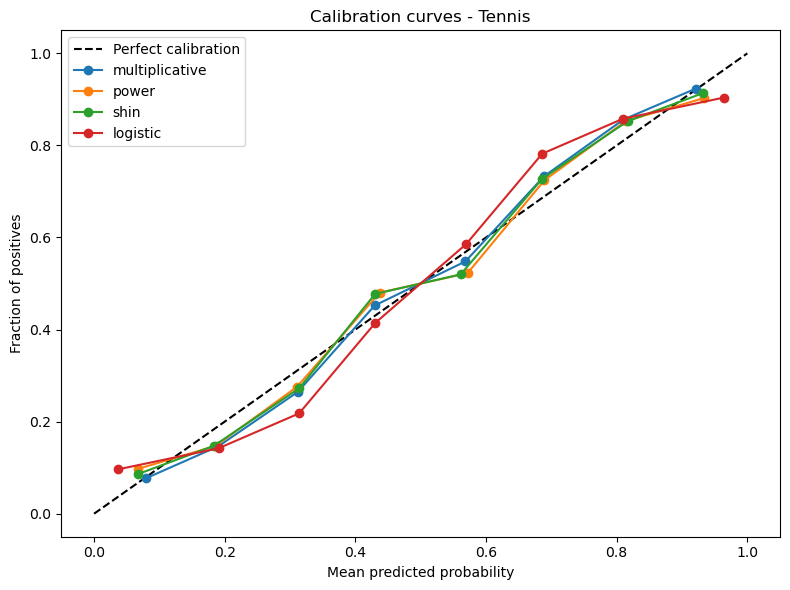

In [33]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

actuals = np.array([1] * len(data_test) + [0] * len(data_test))

models = {
    "multiplicative": ("multiplicativeWinner", "multiplicativeLoser"),
    "power":          ("powerWinner",          "powerLoser"),
    "shin":           ("shinWinner",           "shinLoser"),
    "logistic":       ("logisticProbWinner",   "logisticProbLoser"),
}

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")

for name, (winner_col, loser_col) in models.items():
    probs = np.concatenate([data_test[winner_col], data_test[loser_col]])
    fraction_of_positives, mean_predicted = calibration_curve(actuals, probs, n_bins=8)
    plt.plot(mean_predicted, fraction_of_positives, marker="o", label=name)

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration curves - Tennis")
plt.legend()
plt.tight_layout()
plt.savefig("tennisCal.pdf")
plt.show()